# From Foundational Math to SOTA: A Comparative Study of Architectural Evolution in Satellite Imagery Classification

## Part Two: Implementing a Convolutional Neural Network from Scratch for EuroSAT Image Classification


--------------------------------------------------------

# Introduction: 

### I am doing this project as part of my learning journey in deep learning. Currently, I am taking the Deep Learning Specialization by Deeplearning.AI, and I decided to do this project to make my understanding of the concepts concrete and to improve my overall skills in this lovely path of AI.

### This project is part of the comparative study of from-scratch Neural Networks to TensorFlow on EuroSAT Classification. In this project, I am creating a Convolutional neural network from scratch to classify the Eurosat (RGB) dataset, consisting of 10 classes.

### The architecture of the CNN is based on some of the famous CNN classifaction models for EuroSAT dataset that I found on Kaggle. The architecture is built in following sequence: Input Layer -> Conv. + Max-pooling (1) -> Conv. + Max-pooling (2) -> Conv. + Max-pooling (3) -> Dropout -> -> Conv. + Max-pooling (4) -> Dropout -> Conv. + Max-pooling (5) -> Dropout -> Conv. + Max-pooling (6) -> Global Average Pooling -> Fully Connected Dense layer -> Ouput Layer [softmax], with all convolutional layers with ReLU activations.  



#### ** I tried using vectorized implementation in all parts of my code as possible for optimal performance. **

---

---

### Some of the functions used in this project is influenced by the way I implemented them in the Deep Learning Specialization Course 4.


![Eurosat dataset classification example](https://miro.medium.com/v2/resize:fit:610/1*i5CK72qCucbH6ots5op86w.jpeg)


## The dataset that I am using is the EuroSAT dataset.
### I will be working on the RGB version where there are 10 classes to be classified:

1. AnnualCrop
2. Forest
3. HerbaceousVegatation
4. Highway
5. Industrial
6. Pasture
7. PermanentCrop
8. Residential
9. River
10. SeaLake

**The dataset is being used for classifying the use of land in geospatial images. Each image in the dataset is 64x64 pixels with a Ground Sampling Distance of 10m. They were all collected from the Sentinel-2 satellite.**

**I am using a ready-to-use split & shuffled version of the dataset (total of 27000 examples). The dataset is split into:**
* train.csv ---> 18900 examples
* validation.csv ---> 5400 examples
* test.csv ---> 2700 examples

**Making the split a 70/20/10 split for the train/validation/test respectively.**

## The Convolutional Neural Network Architecture to be implemented:


[![cnn-6block-arch.jpg](https://i.postimg.cc/dtSytqsN/cnn-6block-arch.jpg)](https://postimg.cc/6yn3MxGC)


The Convolutional layer performs spatial feature extraction by sliding learned kernels over the image. These kernels act as adaptive edge and texture detectors that "look" for specific patterns in the pixel data.

The ReLU layer introduces non-linearity and sparsity. By turning negative values into zeros, it effectively "cleans" the feature map so that only the most relevant, active detections are passed forward to the next layer.

The "Block" structure allows the model to transition from low-level pixel information (like lines) to high-level semantic concepts (like shapes or land types). Academically, this is called feature hierarchy, where each block builds more complex meaning from the previous one.

The Dropout layers prevent the model from relying too heavily on specific neurons. This forces the network to find multiple "paths" to the correct answer, which helps avoid variance problems and overfitting.

The Global Average Pooling (GAP) layer condenses the spatial information by taking the average value of each feature map. This transforms the data into a 1D shape that is "NN-friendly" for classification without adding the massive amount of extra parameters that a traditional Flatten layer would.

The Softmax layer is the final step for multi-class classification. It turns the raw output numbers into a probability distribution, giving us a percentage-based result for each of the 10 classes in the EuroSAT dataset.


## How did I approach the project?

For the CNN-from-scratch implementation, I started by getting the functions that I needed from Part One (5-L DNN) to use them here with the needed adjustments to match the spatial requirements of the Convolution process (relu, dense layer, image_processing, one_hot_encode, relu_derivative, softmax, cross-entropy loss, update_parameters, initialize_adam_parameters, update_parameters_ADAM, confusion_matrix, plot learning curves). Then, I approached the implementation using a loop-based structure to make it easier and to make it versatile for any changes later in the future. Thinking about it, I feel like it was the way to go for Part One too, but it's ok for me as I love how there's a variety of the implementation strategies (spread layer-by-layer or loop-based) that I used for the project (even though I acknowledge the layer-by-layer implementation done in Part One is not as efficient). Then, I worked on the HE initilization per layer for parameters, and I made sure that the dimensions are correct from the conv layers to the last dense layer. Next was working on the forward propagation. I used snippets of the code that I wrote in Deep Learning Specialization Course 4 (conv_forward, pool_forward, zero_pad), but I adjusted them to match my implementation and made sure they fit in the loop-based structure. For the conv_forward function, it basically loops through each row, column, and channel and implements the convolution process, then pass the cache and the output forward through the network, same thing was with the pool_forward but with taking the max of the window instead of convoluting it. As for the way I implemented forward propagation, I looped through the architecture, checking each layer then calling the forward prop of that layer, adding the its cache to the main cache, and adjusting the index for layers with parameters. After making sure that the forward propagation is working, I worked on the back propagation using the same approach of creating a backward prop function for each layer (with any other helping function needed), then passing through all layers using a reversed loop that passes from the loss function to the input layer, which is essential to conform to the chain rule needed in the backprop. With the help of layer_cache, which acted as the memory of the network, storing the necessary spatial information per layer, I finished the backpropagation. As usual, I headed to update the gradients right away. I used the same functions (normal vanilla descent update and ADAM optimizer update) in the DNN, just adjusted them to match the CNN's architecture. Then, I implmented the model function to join everything together and finalize my model. One additional thing I added here that wasn't in the DNN is the early stopping technique because as we know CNN is more computationaly requiring than normal NN, so I made sure to optimize the implementation; additionaly, I used cupy from the start to make the model utilize the gpu and take advantage of the parallel computing. After trying to run the model for the first time, I hit a hard wall; the model kept running for 30 minutes without producing any output. After some search, it turned out that the loops that I did in the conv_forward and conv_backward were so intense on the cpu that it couldn't handle running them. So, I replaced the slow, nested loops that processed one image at a time with vectorized operations (using cp.tensordot), which stack the entire batch of images together. This allows the GPU to compute all 64 examples simultaneously in a single matrix operation, speeding up training by roughly 100x. Again, the model is taking on average ten minutes for a single forward pass which means a full training session would take days, which is definitely not tolerable for a research project. After running for a while, the model still utilizes around 100% of the CPU at time of execution, while the GPU is at just 10% utilization (90% idle) which is clearly a bottleneck introduced by the loops in the pool_forward, pool_backward, conv_forward (before vectorization), and conv_backward. So, the best decision is to turn the loops into a vectorized implementation to avoid the bottleneck between the CPU and the GPU. Enters the vectorized sliding window, this was implemented using stride tricks which eliminates the need for any loops inside the functions.

At the end, the stride tricks utilit was used to speed up the implementation for the functions that needed to iterate over the examples, width, height, and channels. This totally improved the speed performance of the model, and the vectorized implementation has prevailed once again.

Even though the model ran fast and everything was going well, we hit a hard wall. The model wasn't learning and the gradients were vanishing, causing the model to have bad costs and accuracies for both the train and val sets. So, I had to do a sanity check and re-adjust some of the functions (pool, back_prop, etc.). In addition, I had to use a sanity check small batch of the model and a simpler model architecture to make sure that everything is ok. The sanity check code was used to debug the vanishing gradients and monitoring why the model wasn't learning. After tweaking some changes and adjusting the parameters it worked and converged successfully, costs drop from ~10 to near-zero (0.0026), accuracy hits 100% by epoch 90 and stays there, and grad norms stabilize without vanishing/exploding.

After some debugging, the problem was that, as my intuition told me, is that there were vanishing gradients caused by the ReLU layer in such a deep CNN network. So, the solution was quite straight forward, Leaky ReLU. Still it didn't change much and the model wasn't working as expected.

Still the model wasn't learning, after all of the debugging and changes that I've made. So as usual, I kept debugging for days and days, until the main problem was found; there was an unnoticed transpose mistake in the conv_forward, conv_backward, and pool_backward functions that prevented the gradients to move correctly through the network; this was like a killer for the gradients and it showed that there was diminishing gradients, but in reality there was no gradients at all. After correcting them, the model showed a promising Training Accuracy: 79.63%
Validation Accuracy: 77.17% for the simplified architecture. However, the full architecture wasn't giving the expected output. I tried adding gradient clipping to to stabilize the network training by preventing the exploding gradients, but it wasn't enough in my case to solve it.

So, I had to keep tuning and debugging to reach a solution. Reaching my limit, I had to go with the obvious solution, using batch normalization to normalize the gradients after finding that they were exploding at the last two blocks of the architecture. This was my last resort, and I didn't want to use it at the beginning to try and experiment with other options as I had already used it in Part 1 of this study (DNN). Finally, the model is learning and giving some really great results comparable to results from using a library-based model. I learned from this experiment a lot, and it showed me how batch normalization was the real MVP in such cases, where deeper networks should be normalized by a technique such that it keeps its gradient intact until the last layer to make sure the learning process is successful.

At last, sadly, I couldn't get the 6-block CNN to work. For some reason, the 6-block CNN kept on giving mediocre results, and to my understanding the problem is mainly caused by some type of bottle-neck between the last 2 blocks and the GAP/Flatten layer. Consequently, I had to use the 3-block model, and I added batch norm to it, which gave a satisfying result of: 
Training Accuracy: 88.75%
Validation Accuracy: 82.78%

### The final 3-block model is based on this Architecture: Input Layer -> Conv. + Batch-Norm + ReLU + Max-pooling (1) -> Conv. + Batch-Norm + ReLU + Max-pooling (2) -> Conv. + Batch-Norm + ReLU + Max-pooling (3) -> Dropout -> Flatten -> Fully Connected Dense layer[64] -> ReLU -> Fully Connected Dense layer[10] -> Ouput Layer [softmax]

This was my approach to this part. It was tedious, but really informative, to work on this part, and am really happy with the results. 


After completing my from-scratch implementation, I built an equivalent 6-block CNN in TensorFlow to use as a baseline comparison. The TensorFlow model reached 93% validation accuracy in under an hour, compared to my from-scratch model's 82.78%, despite using comparable architecture and the same dataset. The performance gap comes down to three things: TensorFlow's Adam optimizer uses production-grade fused CUDA kernels with built-in numerical stability that prevent the momentum overshoot I spent weeks debugging; its internal ops keep activation distributions stable throughout training without requiring explicit BatchNorm; and the GlobalAveragePooling at the end of 6 pooling layers creates a well-conditioned 32-feature bottleneck that naturally avoids vanishing gradients. The gap isn't a failure of my implementation — it's a demonstration of exactly why production libraries exist and what they solve under the hood.

# Implementation:


## Importing needed libraries


In [1]:
import numpy as np 
import cupy as cp
import pandas as pd 
import warnings
import random
import glob
import os
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
# ignoring unwanted warnings for a clean notebook representation
warnings.filterwarnings('ignore')

In [3]:
# Seeding for reproducability
np.random.seed(42)
cp.random.seed(42)
random.seed(42)

## Getting the data ready


In [4]:
train_data = pd.read_csv("/kaggle/input/eurosat-dataset/EuroSAT/train.csv", index_col=False)
test_data = pd.read_csv("/kaggle/input/eurosat-dataset/EuroSAT/test.csv", index_col=False)
val_data = pd.read_csv("/kaggle/input/eurosat-dataset/EuroSAT/validation.csv", index_col=False)

In [5]:
# Dropping unused columns to have a clean Dataframes for training, testing, and validation.

train_data.drop(columns=train_data.columns[[0,3]], axis=1,inplace = True)
test_data.drop(columns=test_data.columns[[0,3]], axis=1,inplace = True)
val_data.drop(columns=val_data.columns[[0,3]], axis=1,inplace = True)

In [6]:
train_data

,Filename,Label
0,AnnualCrop/AnnualCrop_142.jpg,0
1,HerbaceousVegetation/HerbaceousVegetation_2835...,2
2,PermanentCrop/PermanentCrop_1073.jpg,6
3,Industrial/Industrial_453.jpg,4
4,HerbaceousVegetation/HerbaceousVegetation_1810...,2
...,...,...
18895,HerbaceousVegetation/HerbaceousVegetation_1952...,2
18896,Pasture/Pasture_1252.jpg,5
18897,AnnualCrop/AnnualCrop_2332.jpg,0
18898,Residential/Residential_332.jpg,7


### Splitting the data into X and y


In [7]:
X_train = train_data.drop(['Label'], axis = 1)
y_train = train_data['Label'].to_numpy()
y_train_gpu = cp.asarray(y_train)

X_val = val_data.drop(['Label'], axis = 1)
y_val = val_data['Label'].to_numpy()
y_val_gpu = cp.asarray(y_val)
X_test = test_data.drop(['Label'], axis = 1)
y_test = test_data['Label'].to_numpy()

In [8]:
train_paths = X_train["Filename"].values
val_paths = X_val["Filename"].values
test_paths = X_test["Filename"].values

### Preprocessing the data by decoding the jpg images to RGB values then normalizing them


In [9]:
def image_preprocessing(image_paths, size = (64,64)):
    images = []
    base_path = "/kaggle/input/eurosat-dataset/EuroSAT/"
    
    for path in image_paths:
        full_path = os.path.join(base_path, path)
        img = Image.open(f"{full_path}").convert("RGB").resize(size) # Ensuring the same size
        image = cp.array(img, dtype=cp.float32) / 255.0      # Converting to cp.array + Normalizing the values by dividing by 255
        images.append(image)
    return cp.array(images)

In [10]:
m_train = X_train.shape[0]
m_val = X_val.shape[0]
m_test = X_test.shape[0]

X_train_images = image_preprocessing(train_paths)
X_val_images = image_preprocessing(val_paths)
X_test_images = image_preprocessing(test_paths)

In [11]:
X_train_images.shape

(18900, 64, 64, 3)

In [12]:
def one_hot_encode(y, num_classes):
    """
    This function takes in the target y and the number of classes and converts them from label-encoded values to one-hot encoded values for easier handling in the loss function and backpropagation.
    
    Returns: one_hot encoded values of the target values.
    """
    y = y.flatten()  # make sure y is 1D: (m,)
    m = y.shape[0]   # number of examples
    one_hot = cp.zeros((num_classes, m))
    one_hot[y, cp.arange(m)] = 1
    return one_hot

# Ensure labels are 0-9 (some EuroSAT CSVs use 1-10)
y_train = cp.asarray(y_train, dtype=cp.int64)
y_val = cp.asarray(y_val, dtype=cp.int64)
if y_train.min() >= 1 and y_train.max() <= 10:
    y_train, y_val = y_train - 1, y_val - 1  # map 1-10 -> 0-9
    print("Converted labels from 1-10 to 0-9")
y_train_gpu = cp.asarray(y_train)  # refresh GPU arrays after possible conversion
y_val_gpu = cp.asarray(y_val)
y_test_gpu = cp.asarray(y_test)

enc_y_train = one_hot_encode(y_train, 10)
enc_y_val = one_hot_encode(y_val, 10)
enc_y_test = one_hot_encode(y_test, 10)
print(enc_y_train.shape)

(10, 18900)


## Defining the functions to be used


## Potential Model Architectures to be used: 

In [13]:

#cnn_architecture = [
#    # Block 1:
#    {"type": "conv", "filters": 32, "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "relu"},
#    {"type": "pool", "pool_size": 2, "stride": 2, "mode": "max"},
#
#    # Block 2:
#    {"type": "conv", "filters": 64, "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "relu"},
#    {"type": "pool", "pool_size": 2, "stride": 2, "mode": "max"},
#
#    # Block 3:
#    {"type": "conv", "filters": 128, "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "relu"},
#    {"type": "pool", "pool_size": 2, "stride": 2, "mode": "max"},
#    {"type": "dropout", "rate": 0.3},
#
#    # Block 4:
#    {"type": "conv", "filters": 128, "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "relu"},
#    {"type": "pool", "pool_size": 2, "stride": 2, "mode": "max"},
#    {"type": "dropout", "rate": 0.3},
#
#    # ===================== Removed the pool layer (block 5 and 6) for better spatial resolution at the end (2,048 features instead of 128 caused by the collapsing of pool layers)=============
#    # Block 5:
#    {"type": "conv", "filters": 64, "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "relu"},
#    
#    # ===================== Removed the pool layer (block 5 and 6) for better spatial resolution at the end (2,048 features instead of 128 caused by the collapsing of pool layers)=============
#    # Block 6:
#    {"type": "conv", "filters": 32, "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "relu"},
#
#    # Flatten (used instead of Global Average pooling):
#    {"type": "global_average_pooling"},
#
#    # Dense FC layer:
#    {"type": "dense", "units": 64},
#    {"type": "relu"},
#
#    # Output
#    {"type": "dense", "units": 10},  # 10 classes for EuroSat
#    {"type": "softmax"}
#    
#]


# the latest architecture utilizing batch norm to avoid exploding gradients and stabilize the model in the last blocks
#cnn_architecture = [
#    # Block 1:
#    {"type": "conv",      "filters": 32,  "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "batchnorm", "num_channels": 32},
#    {"type": "relu"},
#    {"type": "pool",      "pool_size": 2, "stride": 2, "mode": "max"},
#
#    # Block 2:
#    {"type": "conv",      "filters": 64,  "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "batchnorm", "num_channels": 64},
#    {"type": "relu"},
#    {"type": "pool",      "pool_size": 2, "stride": 2, "mode": "max"},
#
#    # Block 3 — removed dropout
#    {"type": "conv",      "filters": 128, "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "batchnorm", "num_channels": 128},
#    {"type": "relu"},
#    {"type": "pool",      "pool_size": 2, "stride": 2, "mode": "max"},
#    # NO dropout here
#    
#    # Block 4 — removed dropout  
#    {"type": "conv",      "filters": 128, "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "batchnorm", "num_channels": 128},
#    {"type": "relu"},
#    {"type": "pool",      "pool_size": 2, "stride": 2, "mode": "max"},
#    # NO dropout here
#    
#    # Block 5 — added dropout here instead
#    {"type": "conv",      "filters": 128, "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "batchnorm", "num_channels": 128},
#    {"type": "relu"},
#    {"type": "dropout",   "rate": 0.2},
#    
#    # Block 6 — added dropout here instead
#    {"type": "conv",      "filters": 128, "kernel_size": 3, "stride": 1, "pad": 1},
#    {"type": "batchnorm", "num_channels": 128},
#    {"type": "relu"},
#    {"type": "dropout",   "rate": 0.2},
#
#    # Classifier:
#    {"type": "flatten"},
#    {"type": "dense",  "units": 64},
#    {"type": "relu"},
#    {"type": "dense",  "units": 10},
#    {"type": "softmax"}
#]
# Simplified 3 blocks architecture for easier gradient handling to avoid diminishing gradients:
cnn_architecture = [
    # Block 1:
    {"type": "conv",      "filters": 32,  "kernel_size": 3, "stride": 1, "pad": 1},
    {"type": "batchnorm", "num_channels": 32},
    {"type": "relu"},
    {"type": "pool",      "pool_size": 2, "stride": 2, "mode": "max"},

    # Block 2:
    {"type": "conv",      "filters": 64,  "kernel_size": 3, "stride": 1, "pad": 1},
    {"type": "batchnorm", "num_channels": 64},
    {"type": "relu"},
    {"type": "pool",      "pool_size": 2, "stride": 2, "mode": "max"},

    # Block 3:
    {"type": "conv",      "filters": 128, "kernel_size": 3, "stride": 1, "pad": 1},
    {"type": "batchnorm", "num_channels": 128},
    {"type": "relu"},
    {"type": "pool",      "pool_size": 2, "stride": 2, "mode": "max"},
    {"type": "dropout",   "rate": 0.3},

    # Classifier:
    {"type": "flatten"},
    {"type": "dense",  "units": 64},
    {"type": "relu"},
    {"type": "dense",  "units": 10},
    {"type": "softmax"}
]
# USING A SIMPLER ARCHITECTURE FOR SANITY CHECK
#cnn_architecture =   cnn_architecture = [
#      {"type": "flatten"},
#      {"type": "dense", "units": 64},   # 32 -> 64
#      {"type": "relu"},
#      {"type": "dense", "units": 10},
#      {"type": "softmax"},
#  ]

In [14]:
# ReLU function
def relu(Z):
    """
    This function is an activation function called ReLU
    Z: shape (num_classes, m) 
    where m = number of examples
    Returns: output as a matrix of shape (layer_dims[l], m)
    """
    return cp.maximum(0, Z)

In [15]:
def leaky_relu(Z, alpha=0.01):
    """
    This function is an activation function called ReLU
    Z: shape (num_classes, m) 
    alpha: hyperparameter that controls the slope of the activation function for negative input values
    where m = number of examples
    Returns: output as a matrix of shape (layer_dims[l], m)
    """
    return cp.maximum(alpha * Z, Z)

In [16]:
# SOFTMAX function
def softmax(Z):
    """
    Z: shape (num_classes, m) 
       where m = number of examples
    
    Returns: probabilities with same shape
    """
    # For numerical stability
    Z_shifted = Z - cp.max(Z, axis=0, keepdims=True)
    exp_Z = cp.exp(Z_shifted)
    return exp_Z / cp.sum(exp_Z, axis=0, keepdims=True)

In [17]:
def he_initialization(cnn_architecture, input_shape):
    """
    The output is a dictionary of initialized parameters

    cnn_architecture: The architecture implemented in a dictionary as layers
    input_shape = shape of the input of (n_H, n_W, n_C)
    Returns: initial values for the weights and biases.
    """
    parameters = {}
    n_H, n_W, n_C = input_shape
    layer_idx = 1 # To track layers
    bn_idx    = 1   # for gamma/beta (batchnorm)
    current_channels = n_C 

    for layer in cnn_architecture:
        if layer["type"] == "conv":
            f            = layer["kernel_size"]
            out_channels = layer["filters"]
            pad          = layer["pad"]
            stride       = layer["stride"]
            n            = f * f * current_channels
            parameters[f"W{layer_idx}"] = cp.random.randn(f, f, current_channels, out_channels) * cp.sqrt(2. / n)
            parameters[f"b{layer_idx}"] = cp.zeros((1, 1, 1, out_channels))
            n_H = (n_H + 2*pad - f) // stride + 1
            n_W = (n_W + 2*pad - f) // stride + 1
            current_channels = out_channels
            layer_idx += 1

        elif layer["type"] == "batchnorm":
            C = layer["num_channels"]
            parameters[f"gamma{bn_idx}"]       = cp.ones( (1, 1, 1, C))
            parameters[f"beta{bn_idx}"]        = cp.zeros((1, 1, 1, C))
            parameters[f"running_mean{bn_idx}"] = cp.zeros((1, 1, 1, C))
            parameters[f"running_var{bn_idx}"]  = cp.ones( (1, 1, 1, C))
            bn_idx += 1

        elif layer["type"] == "pool":
            f      = layer["pool_size"]
            stride = layer["stride"]
            n_H = (n_H - f) // stride + 1
            n_W = (n_W - f) // stride + 1

        elif layer["type"] == "flatten":
            current_channels = n_H * n_W * current_channels

        elif layer["type"] == "dense":
            units_in  = current_channels
            units_out = layer["units"]
            parameters[f"W{layer_idx}"] = cp.random.randn(units_out, units_in) * cp.sqrt(2. / units_in)
            parameters[f"b{layer_idx}"] = cp.zeros((units_out, 1))
            current_channels = units_out
            layer_idx += 1

    return parameters

In [18]:
def zero_pad(X, pad):
    """
    Pad with zeros all images of the dataset X. The padding is applied to the height and width of an image.
    
    X: python numpy array of shape (m, n_H, n_W, n_C) representing a batch of m images
    pad: integer, amount of padding around each image on vertical and horizontal dimensions
    
    Returns:
    X_pad: padded image of shape (m, n_H + 2 * pad, n_W + 2 * pad, n_C)
    """
    
    X_pad = cp.pad(X,  ((0,0), (pad, pad), (pad, pad), (0,0)), mode = 'constant', constant_values = (0,0))
    
    return X_pad

In [19]:
# functions to turn an image into a matrix for easier computaion

def get_im2col_indices(x_shape, field_height, field_width, padding=1, stride=1):
    # This calculates exactly where each pixel needs to go in the giant matrix
    m, n_C, n_H, n_W = x_shape
    out_height = int((n_H + 2 * padding - field_height) / stride + 1)
    out_width = int((n_W + 2 * padding - field_width) / stride + 1)

    i0 = cp.repeat(cp.arange(field_height), field_width)
    i0 = cp.tile(i0, n_C)
    i1 = stride * cp.repeat(cp.arange(out_height), out_width)
    j0 = cp.tile(cp.arange(field_width), field_height * n_C)
    j1 = stride * cp.tile(cp.arange(out_width), out_height)
    i = i0.reshape(-1, 1) + i1.reshape(1, -1)
    j = j0.reshape(-1, 1) + j1.reshape(1, -1)
    k = cp.repeat(cp.arange(n_C), field_height * field_width).reshape(-1, 1)

    return (k, i, j)


#def im2col_indices(x, field_height, field_width, padding=1, stride=1):
#    # Pads and rearranges the image into columns
#    p = padding
#    x_padded = cp.pad(x, ((0, 0), (0, 0), (p, p), (p, p)), mode='constant')
#    k, i, j = get_im2col_indices(x.shape, field_height, field_width, padding, stride)
#    cols = x_padded[:, k, i, j]
#    cols = cols.transpose(1, 2, 0).reshape(field_height * field_width * x.shape[1], -1)
#    return cols

In [20]:
# This function uses stride tricks to put all utilization on the GPU by creating larger blocks for parallel computation
def im2col_gpu(x, f, stride, pad):
    # Pad on GPU
    x_padded = cp.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)), mode='constant')
    m, C, H, W = x_padded.shape
    
    out_h = (H - f) // stride + 1
    out_w = (W - f) // stride + 1

    # Create a 'view' of the windows using stride tricks
    shape = (m, C, f, f, out_h, out_w)
    s0, s1, s2, s3 = x_padded.strides
    strides = (s0, s1, s2, s3, s2 * stride, s3 * stride)
    
    windows = cp.lib.stride_tricks.as_strided(x_padded, shape=shape, strides=strides)
    
    # Reshape for massive parallel matrix multiplication
    return windows.transpose(1, 2, 3, 0, 4, 5).reshape(C * f * f, -1)

def col2im_gpu(cols, x_shape, f, stride, pad):
    """
    cols: The gradients in column format
    x_shape: Shape of the original input (m, C, H, W)
    f: filter size
    stride: stride
    pad: padding
    """
    m, C, H, W = x_shape
    out_h = (H + 2 * pad - f) // stride + 1
    out_w = (W + 2 * pad - f) // stride + 1
    
    x_padded = cp.zeros((m, C, H + 2 * pad, W + 2 * pad))
    
    k, i, j = get_im2col_indices((m, C, H, W), f, f, pad, stride)
    
    cols_reshaped = cols.reshape(C * f * f, out_h * out_w, m).transpose(2, 0, 1)
    
    # Atomically add the gradients back to the image locations
    # cp.add.at is essential here to handle overlapping regions
    cp.add.at(x_padded, (slice(None), k, i, j), cols_reshaped)

    if pad == 0:
        return x_padded
    return x_padded[:, :, pad:-pad, pad:-pad]

In [21]:
def conv_forward(A_prev, W, b, stride, pad):
    """
    Implements the forward propagation for a convolution function

    A_prev : Input data, numpy array of shape (m, n_H_prev, n_W_prev, n_C_prev)
    W : Weights of the conv layer, numpy array of shape (f, f, n_C_prev, n_C)
    b : Biases of the conv layer, numpy array of shape (1, 1, 1, n_C)
    stride: stride passed in by the architecture dictionary
    pad: pad passed in by the architecture dictionary
        
    Returns:
    Z : conv output, numpy array of shape (m, n_H, n_W, n_C)
    cache : cache of values needed for the conv_backward() function
    """
    # ===================== OLD Implementation using loops =====================
    
    #(m, n_H_prev, n_W_prev, n_C_prev) = A_prev.shape
    #(f, f, n_C_prev, n_C) = W.shape
    #
    #n_H = int(((n_H_prev - f + (2 * pad)) / stride) + 1)
    #n_W = int(((n_W_prev - f + (2 * pad)) / stride) + 1)
    #
    #Z = cp.zeros((m, n_H, n_W, n_C))
    #A_prev_pad = zero_pad(A_prev, pad)
    
    # We loop over Height and Width (Sliding Window), but Vectorize m and n_C 
    #for h in range(n_H):
    #    for w in range(n_W):
    #        vert_start = h * stride
    #        vert_end = vert_start + f
    #        horiz_start = w * stride
    #        horiz_end = horiz_start + f
    #        
    #        # Slice the whole batch at once: shape (m, f, f, n_C_prev)
    #        a_slice_prev = A_prev_pad[:, vert_start:vert_end, horiz_start:horiz_end, :]
    #        
    #        # Vectorized convolution:
    #        # Multiplies (m, f, f, n_C_prev) by (f, f, n_C_prev, n_C)
    #        # Sums over axes 1, 2, 3 (f, f, n_C_prev)
    #        # Result shape: (m, n_C)
    #        Z[:, h, w, :] = cp.tensordot(a_slice_prev, W, axes=([1,2,3], [0,1,2])) + b.reshape(1, n_C)

    # ===================== NEW Implementation using im2col =====================
    
    ## Ensure (m, C, H, W) format
    #if A_prev.shape[3] == W.shape[2]: # If it's (m, H, W, C)
    #    A_prev = A_prev.transpose(0, 3, 1, 2)
    #
    #m, n_C_prev, n_H_prev, n_W_prev = A_prev.shape
    #f, f, _, n_C = W.shape
    #
    #n_H = int((n_H_prev + 2 * pad - f) / stride + 1)
    #n_W = int((n_W_prev + 2 * pad - f) / stride + 1)
    #
    #A_col = im2col_indices(A_prev, f, f, pad, stride) # shape: (f*f*C_prev, m*H_out*W_out)
    #
    #W_flattened = W.transpose(3, 2, 0, 1).reshape(n_C, -1)
    #
    #Z = cp.dot(W_flattened, A_col) + b.reshape(-1, 1)
    #
    #Z = Z.reshape(n_C, n_H, n_W, m).transpose(3, 1, 2, 0) # (m, n_H, n_W, n_C) 
    #
    ## Save information in "cache" for the backprop
    ##cache = (A_prev, W, b, stride, pad)

# ===================== NEW Implementation using stride tricks =====================
    
        # Ensure (m, C, H, W)
    if A_prev.shape[1] != W.shape[2] and A_prev.shape[3] == W.shape[2]:
        A_prev = A_prev.transpose(0, 3, 1, 2)  # (m, H, W, C) -> (m, C, H, W)

    m, C_in, H_in, W_in = A_prev.shape
    f, f2, C_in_w, C_out = W.shape
    assert f == f2 and C_in == C_in_w

    H_out = (H_in + 2 * pad - f) // stride + 1
    W_out = (W_in + 2 * pad - f) // stride + 1

    # Columns on GPU
    A_col = im2col_gpu(A_prev, f, stride, pad)          # (C_in * f * f, m * H_out * W_out)
    W_flat = W.transpose(3, 2, 0, 1).reshape(C_out, -1) # (C_out, C_in * f * f)

    Z = cp.dot(W_flat, A_col) + b.reshape(-1, 1)        # (C_out, m * H_out * W_out)
    Z = Z.reshape(C_out, m, H_out, W_out).transpose(1, 2, 3, 0)

    cache = {
        "A_prev": A_prev,     # stored as (m, C_in, H_in, W_in)
        "W": W,
        "b": b,
        "stride": stride,
        "pad": pad,
        "A_col": A_col
    }
    return Z, cache

In [22]:
def batchnorm_forward(Z, gamma, beta, running_mean, running_var,
                      training=True, momentum=0.9, epsilon=1e-5):
    """
    Z     : (m, H, W, C)
    gamma : (1, 1, 1, C)
    beta  : (1, 1, 1, C)
    Normalises over (m, H, W), keeps C separate.
    Returns Z_out (m,H,W,C) and cache.
    running_mean/var are updated IN-PLACE during training.
    """
    if training:
        mu  = cp.mean(Z, axis=(0, 1, 2), keepdims=True)   # (1,1,1,C)
        var = cp.var( Z, axis=(0, 1, 2), keepdims=True)   # (1,1,1,C)
        Z_norm = (Z - mu) / cp.sqrt(var + epsilon)
        Z_out  = gamma * Z_norm + beta
        # Update running stats (in-place so caller sees the change)
        running_mean[:] = momentum * running_mean + (1 - momentum) * mu
        running_var[:]  = momentum * running_var  + (1 - momentum) * var
        cache = (Z, Z_norm, mu, var, gamma, beta, epsilon)
    else:
        Z_norm = (Z - running_mean) / cp.sqrt(running_var + epsilon)
        Z_out  = gamma * Z_norm + beta
        cache  = None
    return Z_out, cache


In [23]:
# ====================== OLD pool_forward function using loops ================================

def pool_forward(A_prev, pool_size, stride, mode = "max"):
    """
    Implements the forward pass of the pooling layer with both modes: max and avg
    
    A_prev : Input data, numpy array of shape (m, n_H_prev, n_W_prev, n_C_prev)
    pool_size: the size of the pool kernel passed in by the architecture dictionary
    stride: stride passed in by the architecture dictionary
    mode : the pooling mode you would like to use, defined as a string ("max" or "average")
    
    Returns:
    A : output of the pool layer, a numpy array of shape (m, n_H, n_W, n_C)
    cache : cache used in the backward pass of the pooling layer, contains the input and stride, pool_size parameters 
    """
#    
#    (m, n_H_prev, n_W_prev, n_C_prev) = A_prev.shape
#    
#    n_H = int(1 + (n_H_prev - pool_size) / stride)
#    n_W = int(1 + (n_W_prev - pool_size) / stride)
#    n_C = n_C_prev
#    
#    A = cp.zeros((m, n_H, n_W, n_C))              
#    
#    for i in range(m):
#        for h in range(n_H):
#            vert_start = h * stride
#            vert_end = vert_start + pool_size
#            
#            for w in range(n_W):
#                horiz_start = w * stride
#                horiz_end = horiz_start + pool_size
#                
#                for c in range(n_C):
#                    a_prev_slice = A_prev[i, vert_start: vert_end, horiz_start: horiz_end, c]
#                    
#                    if mode == 'max':
#                        A[i, h, w, c] = cp.max(a_prev_slice)
#                    elif mode == 'average':
#                        A[i, h, w, c] = cp.average(a_prev_slice)
#    
#    #cache = (A_prev, pool_size, stride)
#    cache = {"A_prev" : A_prev, "pool_size" : pool_size, "stride" : stride}
#    
#    # Making sure output shape is correct
#    assert(A.shape == (m, n_H, n_W, n_C))
#    
#    return A, cache


# ====================== NEW pool_forward function using im2col ================================

    A_prev_t = A_prev.transpose(0, 3, 1, 2)  # (m, C, H, W)
    m, C, H, W = A_prev_t.shape

    out_h = (H - pool_size) // stride + 1
    out_w = (W - pool_size) // stride + 1

    shape = (m, C, pool_size, pool_size, out_h, out_w)
    s0, s1, s2, s3 = A_prev_t.strides
    strides = (s0, s1, s2, s3, s2 * stride, s3 * stride)

    windows = cp.lib.stride_tricks.as_strided(A_prev_t, shape=shape, strides=strides)

    if mode == "max":
        A_out = cp.max(windows, axis=(2, 3))      # (m, C, out_h, out_w)
    elif mode == "average":
        A_out = cp.mean(windows, axis=(2, 3))
    else:
        raise ValueError("mode must be 'max' or 'average'")

    cache = (A_prev, windows, stride, pool_size, mode)
    return A_out.transpose(0, 2, 3, 1), cache  # (m, out_h, out_w, C), cache


In [24]:
def global_avg_pool_forward(A_prev):
    """
    Implements the forward pass of the global average pooling layer
    
    A_prev : Input data, numpy array of shape (m, n_H_prev, n_W_prev, n_C_prev)
        
    Returns:
    A : output of the global average pooling layer, a numpy array of shape (m, n_C)
    cache : cache used in the backward pass of the global average pooling layer, contains the input and stride, pool_size parameters  
    """

    (m, n_H_prev, n_W_prev, n_C_prev) = A_prev.shape
    
    A = cp.mean(A_prev, axis= (1,2))              

    cache = A_prev.shape
    
    # Making sure output shape is correct
    assert(A.shape == (m, n_C_prev))
    
    return A, cache
    

In [25]:
def flatten_forward(A_prev):
    """
    Flattens the output of the last conv layer to be fed into a dense layer.
    A_prev shape: (m, H, W, C)
    Returns: 
    A: shape (features, m) - Note: Dense layer expects features as rows
    """
    m = A_prev.shape[0]
    # Flatten: (m, -1) -> Transpose to (features, m)
    A = A_prev.reshape(m, -1).T 
    cache = A_prev.shape # Store original shape for backward
    return A, cache

In [26]:
def dense_forward(A_prev, W, b):
    """
    A_prev : Input data, numpy array of shape (m, n_H_prev, n_W_prev, n_C_prev)
    W : Weights of the dense layer
    b : Biases of the dense layer
    
    Returns:
    Z : dense output, numpy array of shape (m, n_H, n_W, n_C)
    cache : cache of values needed for the dense_backward() function
    """
    Z = cp.dot(W, A_prev) + b
    return Z, A_prev

In [27]:
def dropout_forward(A_prev,layer):
    """
    The forward propagation function for a dropout layer 
    
    A_prev: Input data, numpy array of shape (m, n_H_prev, n_W_prev, n_C_prev) 
    layer: the current layer in the architecture dictionary
    """
    keep_prob = 1 - layer["rate"]
    mask = (cp.random.rand(*A_prev.shape) < keep_prob).astype(int)
    A = (A_prev * mask) / (keep_prob)

    cache = mask

    return A, cache

In [28]:
def forward_propagation(X, cnn_architecture, parameters, training = True):
    """
    The architecture implemented in a dictionary as layers
    
    X: Input data, numpy array of shape (m, n_H_prev, n_W_prev, n_C_prev)
    cnn_architecture: The architecture implemented in a dictionary as layers
    parameters: initial values for the weights and biases
    training: training: flag that makes sure dropout is only applied in training and not during evaluation (true = apply , false = don't apply)

    Returns:
    A: final activation of the output layer
    cache: the cache from the forward propagation

    """
    A_current = X
    caches = {}
    param_idx = 1  # index over {conv, dense} layers only
    bn_idx    = 1

    for i, layer in enumerate(cnn_architecture):

        if layer["type"] == "conv":
            W = parameters[f"W{param_idx}"]
            b = parameters[f"b{param_idx}"]
            A_current, cache = conv_forward(A_current, W, b, layer["stride"], layer["pad"])
            caches[i] = cache
            param_idx += 1

        elif layer["type"] == "batchnorm":
            gamma       = parameters[f"gamma{bn_idx}"]
            beta        = parameters[f"beta{bn_idx}"]
            running_mean = parameters[f"running_mean{bn_idx}"]
            running_var  = parameters[f"running_var{bn_idx}"]
            A_current, cache = batchnorm_forward(
                A_current, gamma, beta, running_mean, running_var, training=training)
            caches[i] = (cache, bn_idx)
            bn_idx += 1

        elif layer["type"] in ("flatten", "global_average_pooling"):
            if layer["type"] == "flatten":
                original_shape = A_current.shape
                A_current = A_current.reshape(A_current.shape[0], -1).T
                caches[i] = original_shape
            else:
                A_current, cache = global_avg_pool_forward(A_current)
                A_current = A_current.T
                caches[i] = cache

        elif layer["type"] == "relu":
            caches[i]  = A_current
            A_current  = leaky_relu(A_current)

        elif layer["type"] == "pool":
            A_current, pool_cache = pool_forward(
                A_current, layer["pool_size"], layer["stride"],
                mode=layer.get("mode", "max"))
            caches[i] = pool_cache

        elif layer["type"] == "dropout":
            if training:
                A_current, drop_cache = dropout_forward(A_current, layer)
                caches[i] = drop_cache
            else:
                caches[i] = None

        elif layer["type"] == "dense":
            W = parameters[f"W{param_idx}"]
            b = parameters[f"b{param_idx}"]
            A_current, cache = dense_forward(A_current, W, b)
            caches[i] = cache
            param_idx += 1

        elif layer["type"] == "softmax":
            caches[i]  = None
            A_current  = softmax(A_current)

        else:
            raise ValueError(f"Unknown layer type: {layer['type']}")

    return A_current, caches

In [29]:
def cost_func(X, y, parameters, cnn_architecture, training=True, epsilon=1e-7):
    """
    The function returns the cost function for performance monitoring and supports batch normalization
    
    X: shape (m, H, W, C)
    y: the true label of the examples from the training set. shape: (num_classes, m) - one-hot encoded labels
    cnn_architecture: The architecture implemented in a dictionary as layers
    parameters: initial values for the weights and biases
    training: training: flag that makes sure dropout is only applied in training and not during evaluation (true = apply , false = don't apply)

    
    Returns: 

    cost: the cost result of the predictions
    """
    
    y_pred, _ = forward_propagation(X, cnn_architecture, parameters, training=training)
    
    m = y.shape[1]
    cost = (-cp.sum(y * cp.log(y_pred + epsilon)) / m)
    
    return cp.squeeze(cost)

In [30]:
def dense_backward(dA, m, cache, parameters, params_idx):
    """
    Implement the backward propagation for a dense layer
    
    dA : gradient of the cost with respect to the output of the dense layer (Z), numpy array of shape (m, n_H, n_W, n_C)
    cache : cache of values needed for the dense_backward()
    parameters: initial values for the weights and biases
    
    Returns: 

    dA_prev : gradient of the cost with respect to the input of the dense layer (A_prev)
    dW : gradient of the cost with respect to the weights of the dense layer (W)
    db : gradient of the cost with respect to the biases of the dense layer (b)
    """
    A_prev = cache
    
    # FIXED: Divide by m here for proper normalization
    dW = cp.dot(dA, A_prev.T) / m
    db = cp.sum(dA, axis=1, keepdims=True) / m
    W = parameters[f"W{params_idx}"]
    dA_prev = cp.dot(W.T, dA)

    return dA_prev, dW, db

In [31]:
def leaky_relu_derivative(Z, alpha=0.01):
    dz = cp.ones_like(Z)
    dz[Z < 0] = alpha
    return dz

In [32]:
def conv_backward(dZ, cache):
    """
    Implement the backward propagation for a convolution function
    
    dZ : gradient of the cost with respect to the output of the conv layer (Z), numpy array of shape (m, n_H, n_W, n_C)
    cache : cache of values needed for the conv_backward(), output of conv_forward()
    
    Returns:
    dA_prev : gradient of the cost with respect to the input of the conv layer (A_prev),
               numpy array of shape (m, n_H_prev, n_W_prev, n_C_prev)
    dW : gradient of the cost with respect to the weights of the conv layer (W)
          numpy array of shape (f, f, n_C_prev, n_C)
    db : gradient of the cost with respect to the biases of the conv layer (b)
          numpy array of shape (1, 1, 1, n_C)
    """    
    A_prev = cache["A_prev"]                  # (m, C_in, H_in, W_in)
    W = cache["W"]                            # (f, f, C_in, C_out)
    b = cache["b"]
    stride = cache["stride"]
    pad = cache["pad"]
    A_col = cache["A_col"]                    # (C_in * f * f, m * H_out * W_out)

    m, C_in, H_in, W_in = A_prev.shape
    f, f2, C_in_w, C_out = W.shape
    assert f == f2 and C_in == C_in_w

    # (C_out, H_out * W_out * m)
    dZ_flat = dZ.transpose(3, 0, 1, 2).reshape(C_out, -1)

    # Grad w.r.t W
    dW_flat = cp.dot(dZ_flat, A_col.T)                         # (C_out, C_in * f * f)
    dW = dW_flat.reshape(C_out, C_in, f, f).transpose(2, 3, 1, 0)  # (f, f, C_in, C_out)

    # Grad w.r.t b
    db = cp.sum(dZ, axis=(0, 1, 2), keepdims=True)  # (1, 1, 1, C_out)

    # Grad w.r.t input (via col2im)
    W_flat = W.transpose(3, 2, 0, 1).reshape(C_out, -1)  # (C_out, C_in * f * f)
    dA_col = cp.dot(W_flat.T, dZ_flat)                   # (C_in * f * f, m * H_out * W_out)
    dA_prev_c = col2im_gpu(dA_col, A_prev.shape, f, stride, pad)  # (m, C_in, H_in, W_in)

    # Back to (m, H, W, C)
    dA_prev = dA_prev_c.transpose(0, 2, 3, 1)

    # FIXED: Normalize by batch size for proper gradient scaling
    dW /= m
    db /= m

    return dA_prev, dW, db

In [33]:
def relu_derivative(Z):
    """
    This function derives the relu for the back prop
    Z: shape (num_classes, m)
    where m = number of examples
    Returns: output as a matrix of shape (layer_dims[l], m)
    """
    return (Z > 0).astype(int) # 1 if Z>0 else 0

In [34]:
def dropout_backward(dZ, cache, layer):
    """
    Implement the backward propagation for a dropout function
    
    dZ : gradient of the cost with respect to the output of the conv layer (Z), numpy array of shape (m, n_H, n_W, n_C)
    cache : cache of values needed for the dropout_backward() [mask]
    layer: the current layer in the architecture dictionary
    
    Returns:
    dA_prev: gradient of the cost with respect to the dropout layer
    """
    mask = cache
    keep_prob = 1 - layer["rate"]
    
    dA_prev = dZ * mask
    dA_prev = dA_prev / keep_prob

    return dA_prev

In [35]:
def create_mask_from_window(x):
    """
    Creates a mask from an input matrix x, to identify the max entry of x.
    
    x : Array of shape (f, f)
    
    Returns:
    mask : Array of the same shape as window, contains a True at the position corresponding to the max entry of x.
    """    
    mask = (x == cp.max(x))
    
    return mask

In [36]:
def distribute_value(dz, shape):
    """
    Distributes the input value in the matrix of dimension shape
    
    dz : input scalar
    shape : the shape (n_H, n_W) of the output matrix for which we want to distribute the value of dz
    
    Returns:
    a : Array of size (n_H, n_W) for which we distributed the value of dz
    """    
    (n_H, n_W) = shape
    average = dz / (n_H * n_W)
    a = cp.full((n_H, n_W), average)
    
    return a

In [37]:
def global_avg_pool_backward(dZL, n_H, n_W):
    """
    Implements the backward pass of the global average pooling layer
    
    dZL : input batch of shape (m, n_C)
    n_H, n_W : the shape (n_H, n_W) of the output matrix for which we want to distribute the value of dz
    
    Returns:
    dA : Array of size (n_H, n_W) for which we distributed the value of dz
    """
    m, n_C = dZL.shape

    dA_scaled = dZL / (n_H * n_W)

    dA_reshaped = dA_scaled[:, cp.newaxis, cp.newaxis, :]

    # cp.broadcast_to is highly efficient on the GPU
    dA = cp.broadcast_to(dA_reshaped, (m, n_H, n_W, n_C))

    return dA

In [38]:
def flatten_backward(dA, cache):
    """
    Reshapes the gradient back to the image format.
    dA shape: (features, m)
    cache: The original shape (m, H, W, C)
    """
    shape = cache
    m = cache[0]
    # Transpose back to (m, features) -> Reshape to (m, H, W, C)
    return dA.T.reshape(shape)

In [39]:
def batchnorm_backward(dout, cache):
    """
    dout  : (m, H, W, C)
    Returns dZ (same shape), dgamma (1,1,1,C), dbeta (1,1,1,C).
    Standard BN backward — analytically exact.
    """
    Z, Z_norm, mu, var, gamma, beta, epsilon = cache
    m_hw = dout.shape[0] * dout.shape[1] * dout.shape[2]   # m * H * W

    dbeta  = cp.sum(dout,          axis=(0, 1, 2), keepdims=True)
    dgamma = cp.sum(dout * Z_norm, axis=(0, 1, 2), keepdims=True)

    dZ_norm  = dout * gamma
    dvar     = cp.sum(dZ_norm * (Z - mu) * -0.5 * (var + epsilon)**(-1.5),
                      axis=(0, 1, 2), keepdims=True)
    dmu      = cp.sum(dZ_norm * -1 / cp.sqrt(var + epsilon),
                      axis=(0, 1, 2), keepdims=True) \
             + dvar * cp.mean(-2 * (Z - mu), axis=(0, 1, 2), keepdims=True)
    dZ       = (dZ_norm / cp.sqrt(var + epsilon)
                + dvar * 2 * (Z - mu) / m_hw
                + dmu / m_hw)
    return dZ, dgamma, dbeta

In [40]:
def pool_backward(dA, cache, mode = "max"):
    """
    Implements the backward pass of the pooling layer
    
    dA : gradient of cost with respect to the output of the pooling layer, same shape as A
    cache : cache output from the forward pass of the pooling layer, contains the layer's input and hparameters 
    mode : the pooling mode you would like to use, defined as a string ("max" or "average")
    
    Returns:
    
    dA_prev : gradient of cost with respect to the input of the pooling layer, same shape as A_prev
    """
    #A_prev, windows, stride, f, mode = cache
    #
    #m, n_H, n_W, n_C = dA.shape
    #m, n_H_prev, n_W_prev, n_C = A_prev.shape
    #
    #dA_prev = cp.zeros_like(A_prev)
    #
    #for i in range(m):
    #    for h in range(n_H):
    #        for w in range(n_W):
    #            for c in range(n_C):
    #                vert_start = h * stride
    #                vert_end = vert_start + f
    #                horiz_start = w * stride
    #                horiz_end = horiz_start + f
    #                
    #                if mode == "max":
    #                    a_prev_slice = A_prev[i, vert_start:vert_end, horiz_start:horiz_end, c]
    #                    mask = (a_prev_slice == cp.max(a_prev_slice))
    #                    dA_prev[i, vert_start:vert_end, horiz_start:horiz_end, c] += (dA[i, h, w, c] * mask)
    #                elif mode == "avg":
    #                    da = dA[i, h, w, c]
    #                    shape = (f, f)
    #                    dA_prev[i, vert_start:vert_end, horiz_start:horiz_end, c] += cp.ones(shape) * (da / (f * f))
    #                    
    #assert(dA_prev.shape == A_prev.shape)
    #
    #return dA_prev
                     

    A_prev, windows, stride, f, mode_cache = cache
    # mode argument wins only if explicit; otherwise use cached
    mode = mode if mode is not None else mode_cache

    # windows: (m, C, f, f, out_h, out_w)
    m, C, f1, f2, out_h, out_w = windows.shape
    assert f1 == f2 == f

    dA_t = dA.transpose(0, 3, 1, 2)                    # (m, C, out_h, out_w)
    dA_exp = dA_t[:, :, cp.newaxis, cp.newaxis, :, :]  # (m, C, 1, 1, out_h, out_w)

    if mode == "max":
        max_vals = cp.max(windows, axis=(2, 3), keepdims=True)
        mask = (windows == max_vals)
        d_windows = mask * dA_exp
    elif mode == "average":
        d_windows = cp.ones_like(windows) * dA_exp / (f * f)
    else:
        raise ValueError("mode must be 'max' or 'average'")

    # Convert back using col2im
    d_windows_col = d_windows.transpose(1, 2, 3, 4, 5, 0).reshape(C * f * f, -1)
    dA_prev_c = col2im_gpu(d_windows_col, A_prev.transpose(0, 3, 1, 2).shape, f, stride, pad=0)
    dA_prev = dA_prev_c.transpose(0, 2, 3, 1)  # (m, H, W, C)
    return dA_prev

In [41]:
def back_prop(predictions, caches, parameters, y_train, cnn_architecture):
    """
    The function implements the backpropagation for the model.

    predictions: the predicted output from forward propagation
    cache: dictionary of the values from the forward propagation to get the gradients
    y_train: the true label of the examples from the training set. shape: (num_classes, m)
    cnn_architecture: The architecture implemented in a dictionary as layers

    Returns:

    grads: dictionary that contains the resulted gradients from the back propagation process
    """
    
    grads = {}
    m = y_train.shape[1]

    dA = predictions - y_train

    # Count how many param layers we have (conv + dense)
    param_idx = sum(1 for layer in cnn_architecture if layer["type"] in ("conv", "dense"))
    bn_idx    = sum(1 for l in cnn_architecture if l["type"] == "batchnorm")

    for i in reversed(range(len(cnn_architecture))):
        layer       = cnn_architecture[i]
        layer_cache = caches[i]

        if layer["type"] == "softmax":
            continue

        elif layer["type"] == "dense":
            dA, dW, db = dense_backward(dA, m, layer_cache, parameters, param_idx)
            grads[f"dW{param_idx}"] = dW
            grads[f"db{param_idx}"] = db
            param_idx -= 1

        elif layer["type"] == "global_average_pooling":
            m_batch, n_H, n_W, n_C = layer_cache
            dA = global_avg_pool_backward(dA.T, n_H, n_W)

        elif layer["type"] == "flatten":
            dA = flatten_backward(dA, layer_cache)

        elif layer["type"] == "pool":
            dA = pool_backward(dA, layer_cache, mode=layer.get("mode", "max"))

        elif layer["type"] == "dropout":
            if layer_cache is not None:
                dA = dropout_backward(dA, layer_cache, layer)

        elif layer["type"] == "relu":
            dA = dA * leaky_relu_derivative(layer_cache)

        elif layer["type"] == "batchnorm":
            bn_cache, _ = layer_cache
            if bn_cache is not None:                           
                dA, dgamma, dbeta = batchnorm_backward(dA, bn_cache)
                grads[f"dgamma{bn_idx}"] = dgamma
                grads[f"dbeta{bn_idx}"]  = dbeta
            bn_idx -= 1

        elif layer["type"] == "conv":
            dA, dW, db = conv_backward(dA, layer_cache)
            grads[f"dW{param_idx}"] = dW
            grads[f"db{param_idx}"] = db
            param_idx -= 1

        else:
            raise ValueError(f"Unknown layer type during backprop: {layer['type']}")

    return grads

In [42]:
def update_parameters(parameters, grads, cnn_architecture, lr = 0.001):
    """
    The function is responsible for updating the parameters with the new gradients that came from the back propagation function with classic gradient descent updates.

    parameters: dictionary of weights and biases to be updated
    grads: dictionary of the gradients that will be used to update the parameters    
    cnn_architecture: The architecture implemented in a dictionary as layers
    lr: learning rate value. (initially 0.001)
    """
    new_parameters = {}
    layer_idx = 1
    for layer in cnn_architecture:
        if layer["type"] in ("conv", "dense"):
            new_parameters[f"W{layer_idx}"] = parameters[f"W{layer_idx}"] - lr * grads[f"dW{layer_idx}"]
            new_parameters[f"b{layer_idx}"] = parameters[f"b{layer_idx}"] - lr * grads[f"db{layer_idx}"]
            layer_idx += 1
    return new_parameters

In [43]:
def initialize_adam_parameters(parameters):
    """
    Initializes the velocity (V) and squared gradient (S) dictionaries for ADAM optimizer.
    
    parameters: dictionary of weights and biases {'W1', 'b1', 'W2', 'b2', ...}
    
    Returns: Vdw, Vdb, Sdw, Sdb initialization dictionaries for the Adam optimizer
    """
    
    Vdw, Vdb, Sdw, Sdb = {}, {}, {}, {}
    Vgamma, Vbeta, Sgamma, Sbeta = {}, {}, {}, {}

    num_W = len([k for k in parameters if k.startswith('W')])
    for l in range(1, num_W + 1):
        Vdw[f"W{l}"] = cp.zeros_like(parameters[f"W{l}"])
        Vdb[f"b{l}"] = cp.zeros_like(parameters[f"b{l}"])
        Sdw[f"W{l}"] = cp.zeros_like(parameters[f"W{l}"])
        Sdb[f"b{l}"] = cp.zeros_like(parameters[f"b{l}"])

    num_bn = len([k for k in parameters if k.startswith('gamma')])
    for l in range(1, num_bn + 1):
        Vgamma[f"gamma{l}"] = cp.zeros_like(parameters[f"gamma{l}"])
        Vbeta[ f"beta{l}"]  = cp.zeros_like(parameters[f"beta{l}"])
        Sgamma[f"gamma{l}"] = cp.zeros_like(parameters[f"gamma{l}"])
        Sbeta[ f"beta{l}"]  = cp.zeros_like(parameters[f"beta{l}"])

    return Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta

In [44]:
def update_parameters_ADAM(parameters, cnn_architecture, grads, Vdw, Vdb, Sdw, Sdb,
                            Vgamma, Vbeta, Sgamma, Sbeta,
                            lr=0.001, beta_m=0.9, beta_rms=0.999, t=2):
    """
    The function is responsible for updating the parameters with the new gradients that came from the back propagation function utilizing the Adaptive Moment Estimation optimizer that basically integrates the Momentum and RMSprop optimizers into one robust optimizer with bias correction.

    parameters: dictionary of weights and biases to be updated
    cnn_architecture: The architecture implemented in a dictionary as layers
    grads: dictionary of the gradients that will be used to update the parameters    
    Vdw, Vdb, Sdw, Sdb initialization dictionaries for the Adam optimizer
    lr: learning rate value. (initially 0.001)
    beta_m: the parameter beta used with the Momentum using exponentially weighted averages optimizer to update the gradients
    beta_rms: the parameter beta used with the RMSprop optimizer to update the gradients
    t: parameter for bias correction (epoch number)
    """
    
    new_parameters = {k: v for k, v in parameters.items()
                      if k.startswith('running')}   # carry running stats unchanged
    epsilon   = 1e-7
    layer_idx = 1
    bn_idx    = 1

    for layer in cnn_architecture:
        if layer["type"] in ("conv", "dense"):
            for key, V, S, grad_key in [
                (f"W{layer_idx}", Vdw, Sdw, f"dW{layer_idx}"),
                (f"b{layer_idx}", Vdb, Sdb, f"db{layer_idx}"),
            ]:
                V[key]  = beta_m   * V[key]  + (1 - beta_m)   * grads[grad_key]
                S[key]  = beta_rms * S[key]  + (1 - beta_rms) * grads[grad_key]**2
                Vc = V[key] / (1 - beta_m**t)
                Sc = S[key] / (1 - beta_rms**t)
                new_parameters[key] = parameters[key] - lr * Vc / (cp.sqrt(Sc) + epsilon)
            layer_idx += 1

        elif layer["type"] == "batchnorm":
            for key, V, S, grad_key in [
                (f"gamma{bn_idx}", Vgamma, Sgamma, f"dgamma{bn_idx}"),
                (f"beta{bn_idx}",  Vbeta,  Sbeta,  f"dbeta{bn_idx}"),
            ]:
                V[key]  = beta_m   * V[key]  + (1 - beta_m)   * grads[grad_key]
                S[key]  = beta_rms * S[key]  + (1 - beta_rms) * grads[grad_key]**2
                Vc = V[key] / (1 - beta_m**t)
                Sc = S[key] / (1 - beta_rms**t)
                new_parameters[key] = parameters[key] - lr * Vc / (cp.sqrt(Sc) + epsilon)
            bn_idx += 1

    return new_parameters, Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta

In [45]:
def schedule_lr_decay(learning_rate0, epoch_num, decay_rate, time_interval=25):
    """
    Calculates updated the learning rate using exponential weight decay with fixed interval scheduling.

    learning_rate0 : Original learning rate. Scalar
    epoch_num : Epoch number. Integer.
    decay_rate : Decay rate. Scalar.
    time_interval : Number of epochs to update the learning rate.

    Returns:
    learning_rate : Updated learning rate. Scalar 
    """
    learning_rate = 1 / (1 + (decay_rate * cp.floor(epoch_num/time_interval))) * learning_rate0
    
    return learning_rate

In [46]:
def create_mini_batches(X, y, batch_size):
    """
    creates mini batches for the model
    
    X: Input data, numpy array of shape (m, n_H, n_W, n_C)
    y: the true label of the examples. shape: (m, num_classes)
    batch_size: the number of batches to be created from the data

    returns:
    mini_batches: mini batches created by the function
    """
    m = X.shape[0]
    permutation = list(cp.random.permutation(m))
    shuffled_X = X[permutation, :, :, :]
    shuffled_y = y[:, permutation]
    
    mini_batches = []
    num_complete_minibatches = m // batch_size

    for k in range(0, num_complete_minibatches):
        mini_batch_X = shuffled_X[k * batch_size : (k + 1) * batch_size, :, :, :]
        mini_batch_Y = shuffled_y[:, k * batch_size : (k + 1) * batch_size]
        mini_batches.append((mini_batch_X, mini_batch_Y))
    
    if m % batch_size != 0:
        mini_batch_X = shuffled_X[num_complete_minibatches * batch_size :, :, :, :]
        mini_batch_Y = shuffled_y[:, num_complete_minibatches * batch_size :]
        mini_batches.append((mini_batch_X, mini_batch_Y))
    
    return mini_batches

# Prediction:


## Model function that implements the Deep Neural Network


In [47]:
# Helper function that prevents OutOfMemoryError that is caused because of the loading of the entire validation set while the GPU is occupied by other computations
def evaluate_model_in_batches(X, Y, parameters, cnn_architecture, batch_size=64):
    """
    Calculates cost and accuracy in batches to avoid OutOfMemoryError
    """
    m = X.shape[0]
    num_batches = 0
    total_cost = 0
    
    minibatches = create_mini_batches(X, Y, batch_size)
    
    for batch_X, batch_Y in minibatches:
        # Calculate cost for this batch (Training=False to disable Dropout)
        batch_cost = cost_func(batch_X, batch_Y, parameters, cnn_architecture, training=False)
        
        # Weighted average accumulation
        current_m = batch_Y.shape[1]
        total_cost += batch_cost * current_m
        
    avg_cost = total_cost / m
    return avg_cost

In [48]:
def model(X_train, Y_train, X_val, Y_val, cnn_architecture, optimizer="adam", learning_rate = 0.005, mini_batch_size = 32, num_epochs = 100, decay_rate = 1, patience = 10, print_cost = True):
    """
    Fits the convolutional neural network to the training data using mini-batch gradient descent 
    and implements early stopping based on validation cost.

    X_train: training image data. shape: (m, n_H, n_W, n_C)
    Y_train: true labels for training set. shape: (m, num_classes)
    X_val: validation image data. shape: (m_val, n_H, n_W, n_C)
    Y_val: true labels for validation set. shape: (m_val, num_classes)
    cnn_architecture: the architecture implemented in a dictionary as layers
    optimizer: the optimization algorithm to use, defined as a string ("adam" or "gd")
    learning_rate: the step size for parameter updates. scalar
    mini_batch_size: size of each mini-batch for the training process. integer
    num_epochs: maximum number of iterations over the training set. integer
    patience: number of epochs to wait for improvement before stopping training. integer
    print_cost: if True, prints the training and validation cost every 10 epochs. boolean

    Returns:
    best_parameters: dictionary of weights and biases that achieved the lowest validation cost
    train_costs: list of average training costs recorded per epoch
    val_costs: list of validation costs recorded per epoch
    """

    # Initialization
    input_shape = X_train.shape[1:]

    parameters = he_initialization(cnn_architecture, input_shape)
    Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta = initialize_adam_parameters(parameters)
    learning_rate0 = learning_rate
    train_accs = []
    val_accs   = []
    train_costs = []
    val_costs = []
    t = 0
    
    # Early Stopping vars
    best_val_cost = float('inf')
    epochs_without_imp = 0
    best_parameters = None

    for epoch in range(1, num_epochs + 1):
        # Training on mini-batches
        minibatches = create_mini_batches(X_train, Y_train, mini_batch_size)
        epoch_cost = 0

        for minibatch in minibatches:
            batch_X, batch_Y = minibatch

            # Forward, Backward props, and updating the gradient
            
            predictions, caches = forward_propagation(batch_X, cnn_architecture, parameters)
            batch_cost = -cp.sum(batch_Y * cp.log(predictions + 1e-7)) / batch_Y.shape[1] # to avoid running the forward_prop twice
            epoch_cost += batch_cost

            grads = back_prop(predictions, caches, parameters, batch_Y, cnn_architecture)
            # Apply gradient clipping to prevent explosion
            grads, total_grad_norm = clip_gradients(grads, max_norm=5.0)
            grad_norms = {k: float(cp.linalg.norm(v)) for k, v in grads.items() if k.startswith('dW')}
            
            t += 1
            
            if optimizer == "adam":
                parameters, Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta = update_parameters_ADAM(
                parameters, cnn_architecture, grads,
                Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta,
                lr=learning_rate, t=t
                )

            else:
                parameters = update_parameters(parameters, grads, cnn_architecture, learning_rate)

        learning_rate = schedule_lr_decay(learning_rate0, epoch, decay_rate)

        # Track training costs        
        train_cost  = epoch_cost / len(minibatches)
        train_costs.append(train_cost)
        
        # === Evaluate in batches to prevent Memory Crash ===
        val_cost = evaluate_model_in_batches(X_val, Y_val, parameters, cnn_architecture, mini_batch_size)
        val_costs.append(val_cost)

        # Early stopping check
        min_delta = 0.001  
        
        if val_cost < (best_val_cost - min_delta):  # <--- UPDATED CONDITION
            best_val_cost = val_cost
            best_parameters = {k: v.copy() for k, v in parameters.items()} 
            epochs_without_imp = 0
        else:
            epochs_without_imp += 1

        if print_cost and epoch % 1 == 0:
            # Batched prediction for training set
            train_preds = predict(X_train, cnn_architecture, parameters, batch_size=mini_batch_size)
            train_acc = cp.mean(train_preds == cp.argmax(Y_train, axis=0)) * 100
            train_accs.append(float(cp.mean(train_preds == cp.argmax(Y_train, axis=0)) * 100))

            # Batched prediction for validation set
            val_preds = predict(X_val, cnn_architecture, parameters, batch_size=mini_batch_size)
            val_acc = cp.mean(val_preds == cp.argmax(Y_val, axis=0)) * 100
            val_accs.append(float(cp.mean(val_preds == cp.argmax(Y_val, axis=0)) * 100))

            print(f"Epoch {epoch}: Train Cost={train_cost:.4f}, Val Cost={val_cost:.4f}, Train Acc={float(train_acc):.2f}%, Val Acc={float(val_acc):.2f}%, No improve={epochs_without_imp}")
            print(f"Epoch {epoch} Grad norms: {grad_norms}")
        
        # Stop if no improvements
        if epochs_without_imp >= patience:
            print(f"\nEarly stopping at epoch {epoch}. Best val cost: {best_val_cost:.4f}")
            return best_parameters, train_costs, val_costs, train_accs, val_accs
        

    print(f"Training completed. Best val cost: {best_val_cost:.4f}")
    return best_parameters, train_costs, val_costs, train_accs, val_accs

In [49]:
def clip_gradients(gradients, max_norm=5.0):
    """
    Clips gradients to prevent explosion
    
    gradients: dictionary of gradients
    max_norm: maximum allowed gradient norm
    
    Returns: clipped gradients, total gradient norm
    """
    # Calculate total gradient norm across all weight gradients
    total_norm = 0.0
    for key in gradients:
        if key.startswith('dW'):
            total_norm += float(cp.sum(gradients[key] ** 2))
    
    total_norm = cp.sqrt(total_norm)
    
    clip_coef = max_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for key in gradients:
            gradients[key] = gradients[key] * clip_coef
    
    return gradients, float(total_norm)


In [50]:
def plot_learning_curves(train_costs, val_costs, train_acc, val_acc, save_path=None):
    """
    Plots Cost and Accuracy in side-by-side subplots.
    Handles both lists (history) and scalars (final values) for accuracy.
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # --- Subplot 1: Cost (Loss) ---
    ax[0].plot([float(c) for c in train_costs], label='train')
    ax[0].plot([float(c) for c in val_costs], label='validation')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Cost')
    ax[0].set_title('Cost vs Epoch')
    ax[0].legend()

    # --- Subplot 2: Accuracy ---
    
    def is_sequence(x):
        if isinstance(x, list):
            return True
        if isinstance(x, np.ndarray):
            return x.ndim > 0  
        return False

    # Plot Train Accuracy
    if is_sequence(train_acc):
        ax[1].plot([float(c) for c in train_acc], label='train')
    else:
        ax[1].axhline(y=float(train_acc), color='tab:blue', label=f'Final Train Acc: {float(train_acc):.2f}%')

    # Plot Validation Accuracy
    if is_sequence(val_acc):
        ax[1].plot([float(c) for c in val_acc], label='validation')
    else:
        ax[1].axhline(y=float(val_acc), color='tab:orange', linestyle='--', label=f'Final Val Acc: {float(val_acc):.2f}%')
    ax[1].set_ylim([0, 100])
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy (%)')
    ax[1].set_title('Accuracy vs Epoch')
    ax[1].legend()

    if save_path:
        plt.savefig(save_path + 'loss_accuracy_curve.png')

    plt.tight_layout()
    plt.show()

In [51]:
def plot_euro_sat_confusion_matrix(y_true, y_pred):
    class_names = [
        "AnnualCrop", "Forest", "HerbaceousVeg", "Highway", "Industrial",
        "Pasture", "PermanentCrop", "Residential", "River", "SeaLake"
    ]
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: EuroSAT Classes')
    plt.show()

In [52]:
def predict(X, cnn_architecture, parameters, batch_size=64):
    m = X.shape[0]
    predictions = []

    for i in range(0, m, batch_size):
        X_batch = X[i : i + batch_size]
        
        # Forward prop (Training=False)
        y_pred_batch, _ = forward_propagation(X_batch, cnn_architecture, parameters, training=False)
        
        # Get labels
        batch_preds = cp.argmax(y_pred_batch, axis=0)
        predictions.append(batch_preds)
        
    # Concatenate all batch results into one array
    return cp.concatenate(predictions)

### Sanity check code used to debug the vanishing gradients and monitoring why the model wasn't learning. After tweaking some changes and adjusting the parameters it worked and converged successfully, costs drop from ~10 to near-zero (0.0026), accuracy hits 100% by epoch 90 and stays there, and grad norms stabilize without vanishing/exploding.


---


# Diagnostics:


In [53]:

# CRITICAL: Use a separate variable so we don't overwrite the main 'parameters' used elsewhere!
# The 5-sample sanity check trains on only 5 examples - if 'parameters' were used, cell 69
# and other diagnostics would wrongly use these overfit params (first 5 correct, rest random).
X_small = X_train_images[:5] 
Y_small = enc_y_train[:, :5]

print("X_small shape:", X_small.shape)
print("Y_small shape:", Y_small.shape)


params_sanity_check = he_initialization(cnn_architecture, X_small.shape[1:])

learning_rate = 0.0001
num_iterations = 100

def update_parameters_simple(parameters, grads, lr):
    for key in parameters:
        if key.startswith('moving'): continue 
        if f"d{key}" in grads:
            parameters[key] -= lr * grads[f"d{key}"]
    return parameters

for i in range(num_iterations):
    
    AL, caches = forward_propagation(X_small, cnn_architecture, params_sanity_check, training=True)
    
    # Cost (Correct function name: cost_func)
    cost = cost_func(X_small, Y_small, params_sanity_check, cnn_architecture)
    
    # Backward (Correct function name: back_prop)
    grads = back_prop(AL, caches, params_sanity_check, Y_small, cnn_architecture)
    
    # Update
    params_sanity_check = update_parameters_simple(params_sanity_check, grads, learning_rate)
    
    if i % 10 == 0:
        # Check accuracy
        predictions = cp.argmax(AL, axis=0)
        labels = cp.argmax(Y_small, axis=0)
        acc = cp.mean(predictions == labels) * 100
        print(f"Iter {i} | Cost: {cost:.4f} | Acc: {acc:.2f}%")


X_small shape: (5, 64, 64, 3)
Y_small shape: (10, 5)
Iter 0 | Cost: 3.1742 | Acc: 0.00%
Iter 10 | Cost: 2.6837 | Acc: 0.00%
Iter 20 | Cost: 1.6375 | Acc: 60.00%
Iter 30 | Cost: 1.1733 | Acc: 80.00%
Iter 40 | Cost: 0.6276 | Acc: 100.00%
Iter 50 | Cost: 0.2679 | Acc: 80.00%
Iter 60 | Cost: 0.4035 | Acc: 100.00%
Iter 70 | Cost: 0.2328 | Acc: 100.00%
Iter 80 | Cost: 0.2384 | Acc: 100.00%
Iter 90 | Cost: 0.0755 | Acc: 100.00%


In [54]:
# Use final_params (from full training in cell 76) - NOT the 5-sample params from cell 68!
#params_to_use = globals().get('final_params') or globals().get('params_sanity_check')
#if params_to_use is None:
#    raise RuntimeError("Run cell 76 (full training) first! Or run cell 68 for sanity-check params.")
#if params_to_use is params_sanity_check:
#    print("WARNING: Using 5-sample params - first 5 will be correct, rest will be random. Run cell 76 for full model.")
#
#AL, _ = forward_propagation(X_train_images[:200], cnn_architecture, params_to_use, training=False)
#preds = cp.argmax(AL, axis=0)
## Class distribution - if one class dominates, model has collapsed (predicting same class for all)
#unique, counts = cp.unique(preds, return_counts=True)
#print("Prediction distribution (class -> count):", dict(zip(unique.tolist(), counts.tolist())))
#acc = float(cp.mean(preds == y_train_gpu[:200]) * 100)
#print(f"Accuracy on first 200 train samples: {acc:.1f}%")
#if acc < 20 and len(unique) <= 2:
#    print(">>> MODEL COLLAPSE: predicting mostly one class. Try more epochs, lower LR, or check gradients.")


In [55]:
# Create one single batch
mini_X = X_train_images[:16]
mini_Y = enc_y_train[:, :16]

params, train_costs, val_costs, train_accs, val_accs = model(
    mini_X, mini_Y, mini_X, mini_Y,
    cnn_architecture,
    optimizer="adam",
    learning_rate=0.0001,    
    mini_batch_size=16,
    num_epochs=200,          # allow more steps
    decay_rate=0.95,
    patience=500,
    print_cost=False
)


Training completed. Best val cost: 0.0025


## Sanity-check diagnostics

If training seems stuck around ~2.30 loss (random guessing for 10 classes) even though gradients are non-zero



In [56]:
# Tiny-batch diagnostics
mini_X = X_train_images[:16]
mini_Y = enc_y_train[:, :16]

# Init params
params0 = he_initialization(cnn_architecture, mini_X.shape[1:])
Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta = initialize_adam_parameters(params0)

# Forward
probs0, caches0 = forward_propagation(mini_X, cnn_architecture, params0, training=False)
softmax_sums = cp.sum(probs0, axis=0)
print('softmax sum stats (min/mean/max):', float(cp.min(softmax_sums)), float(cp.mean(softmax_sums)), float(cp.max(softmax_sums)))

loss0 = cost_func(mini_X, mini_Y, params0, cnn_architecture, training=False)
print('initial loss:', float(loss0))

# One backward/update step
grads0 = back_prop(probs0, caches0, params0, mini_Y, cnn_architecture)
print('grad norms (dW):', {k: float(cp.linalg.norm(v)) for k, v in grads0.items() if k.startswith('dW')})

params1, Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta = update_parameters_ADAM(
                params0, cnn_architecture, grads,
                Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta,
                lr=0.001)
loss1 = cost_func(mini_X, mini_Y, params1, cnn_architecture, training=False)
print('loss after 1 Adam step:', float(loss1))


softmax sum stats (min/mean/max): 0.9999999999999998 1.0 1.0000000000000002
initial loss: 3.222355503672796
grad norms (dW): {'dW5': 3.2454048352933973, 'dW4': 47.41031852572721, 'dW3': 10.328426999518886, 'dW2': 5.162696544850575, 'dW1': 2.853094227818238}
loss after 1 Adam step: 4.647408036589961


In [57]:
mini_X = X_train_images[:16]
mini_Y = enc_y_train[:, :16]

params = he_initialization(cnn_architecture, mini_X.shape[1:])
Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta = initialize_adam_parameters(params)

for step in range(1, 101):
    probs, caches = forward_propagation(mini_X, cnn_architecture, params, training=True)
    loss = cost_func(mini_X, mini_Y, params, cnn_architecture, training=False)
    grads = back_prop(probs, caches, params, mini_Y, cnn_architecture)
    params, Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta = update_parameters_ADAM(
                params0, cnn_architecture, grads,
                Vdw, Vdb, Sdw, Sdb, Vgamma, Vbeta, Sgamma, Sbeta,
                lr=0.001)
    if step % 10 == 0:
        print(f"step {step}: loss={float(loss):.4f}")

step 10: loss=1.8469
step 20: loss=1.4368
step 30: loss=1.1261
step 40: loss=0.7718
step 50: loss=0.4326
step 60: loss=0.3960
step 70: loss=0.3361
step 80: loss=0.3366
step 90: loss=0.6250
step 100: loss=0.3862


---


# Output:


In [58]:
final_params, train_costs, val_costs, train_accs, val_accs = model(
    X_train          = X_train_images,
    Y_train          = enc_y_train,
    X_val            = X_val_images,
    Y_val            = enc_y_val,
    cnn_architecture = cnn_architecture,
    optimizer        = "adam",
    learning_rate    = 0.001,
    mini_batch_size  = 64,
    num_epochs       = 100,
    decay_rate       = 0.3,
    patience         = 25,
    print_cost       = True
)
train_predictions = predict(X_train_images, cnn_architecture, final_params)
val_predictions   = predict(X_val_images,   cnn_architecture, final_params)

Epoch 1: Train Cost=1.2588, Val Cost=1.1793, Train Acc=53.98%, Val Acc=53.70%, No improve=0
Epoch 1 Grad norms: {'dW5': 2.6033330554276617, 'dW4': 3.7442015142203013, 'dW3': 1.4356045860558577, 'dW2': 0.9586846325713889, 'dW1': 0.4133332705925839}
Epoch 2: Train Cost=0.8912, Val Cost=1.7366, Train Acc=49.26%, Val Acc=50.00%, No improve=1
Epoch 2 Grad norms: {'dW5': 2.834544039695533, 'dW4': 3.6289169691401617, 'dW3': 1.6283035452660655, 'dW2': 0.9950699205135839, 'dW1': 0.3934154271550178}
Epoch 3: Train Cost=0.7958, Val Cost=0.7195, Train Acc=74.97%, Val Acc=73.78%, No improve=0
Epoch 3 Grad norms: {'dW5': 3.81651628048417, 'dW4': 2.772894141244257, 'dW3': 1.4642164545596597, 'dW2': 0.7353887044188028, 'dW1': 0.246018920680474}
Epoch 4: Train Cost=0.7957, Val Cost=1.1904, Train Acc=60.46%, Val Acc=60.78%, No improve=1
Epoch 4 Grad norms: {'dW5': 3.9884787949120213, 'dW4': 2.493898501759843, 'dW3': 1.5724525406153802, 'dW2': 0.6028686089180777, 'dW1': 0.19089927000832468}
Epoch 5: Trai

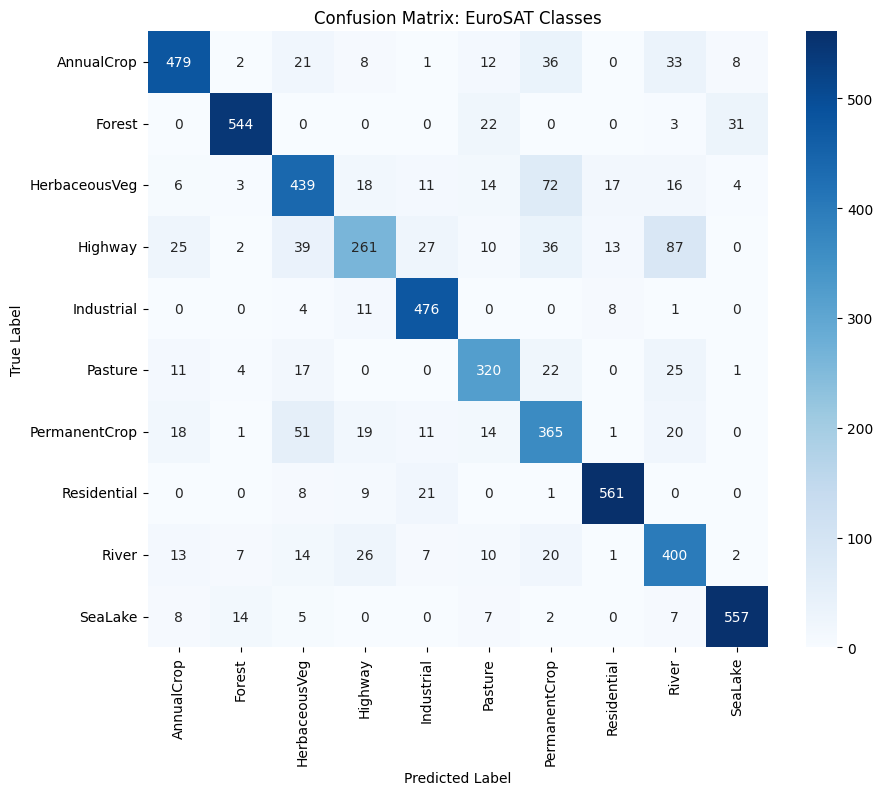

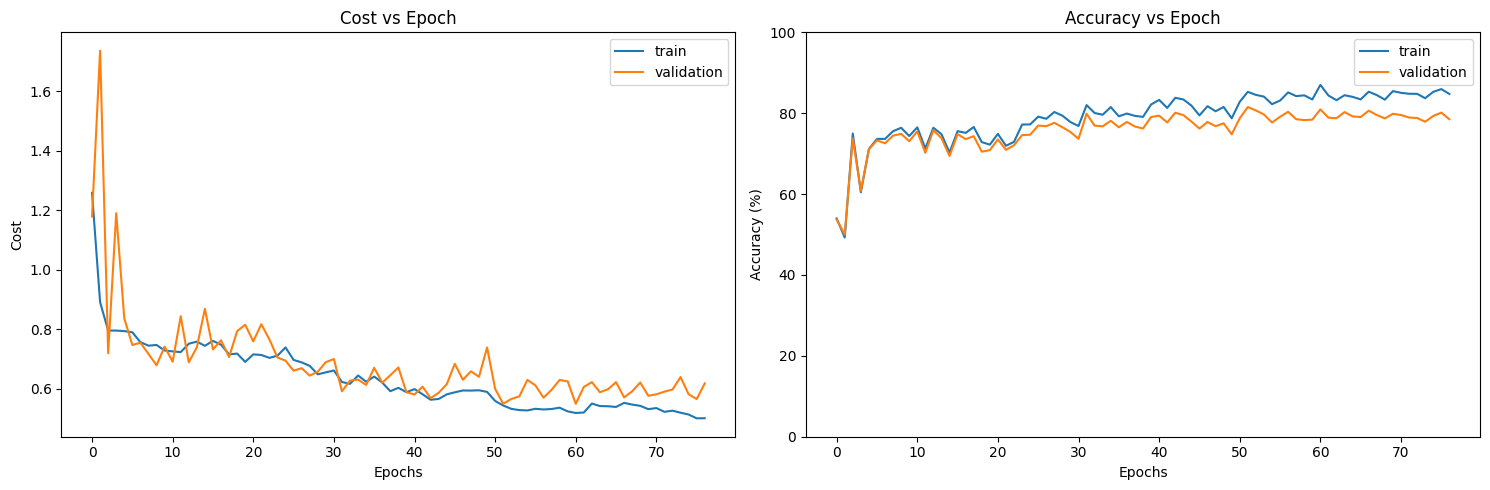

Training Accuracy: 85.29%
Validation Accuracy: 81.52%


In [59]:
# Compute accuracies
train_accuracy = cp.mean(train_predictions == y_train_gpu) * 100
val_accuracy = cp.mean(val_predictions == y_val_gpu) * 100

val_predictions_c = cp.asnumpy(val_predictions)
train_accuracy_c = cp.asnumpy(train_accuracy)
val_accuracy_c = cp.asnumpy(val_accuracy)

# Plot confusion matrix
plot_euro_sat_confusion_matrix(y_val.get(), val_predictions_c)

# Plot learning curves
plot_learning_curves(train_costs, val_costs, train_accs, val_accs)

print(f"Training Accuracy: {float(train_accuracy):.2f}%")
print(f"Validation Accuracy: {float(val_accuracy):.2f}%")

### Test Accuracy

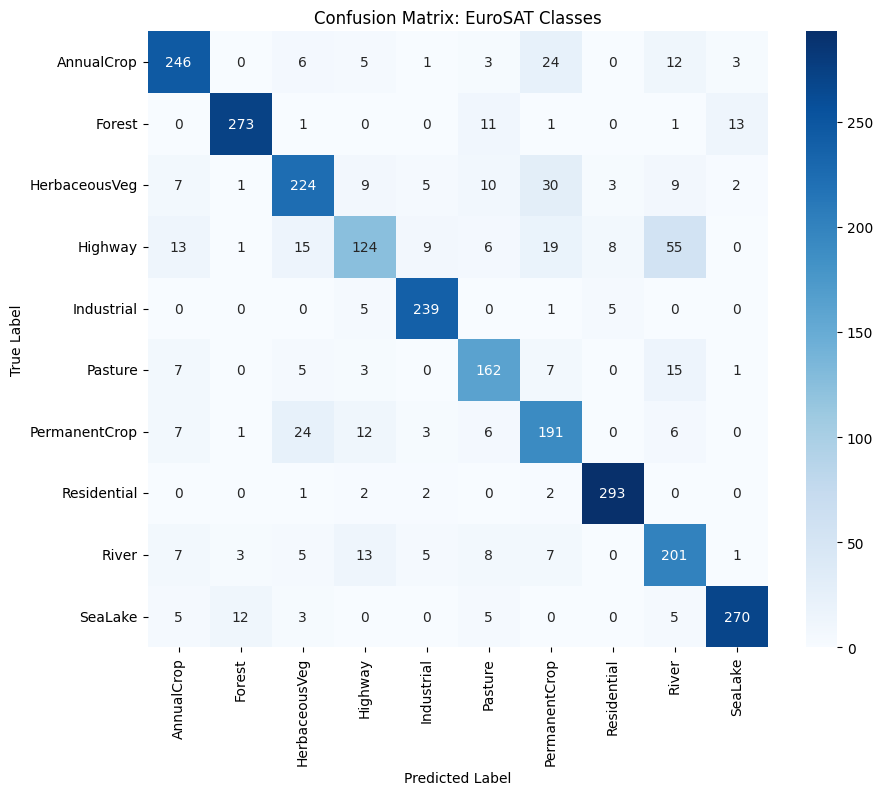

Test Accuracy: 82.33%


In [60]:
test_predictions = predict(X_test_images, cnn_architecture, final_params)

test_accuracy = cp.mean(test_predictions == y_test_gpu) * 100

test_predictions_c = cp.asnumpy(test_predictions)
test_accuracy_c = cp.asnumpy(test_accuracy)

plot_euro_sat_confusion_matrix(y_test, test_predictions_c)

print(f"Test Accuracy: {float(test_accuracy_c):.2f}%")

### Exporting the model for deployment:

In [61]:
import pickle

numpy_params = {k: cp.asnumpy(v) for k, v in final_params.items()}

clean_train_costs = [float(x) for x in train_costs]
clean_val_costs = [float(x) for x in val_costs]
clean_train_accs = [float(x) for x in train_accs]
clean_val_accs = [float(x) for x in val_accs]

model_data_cpu = {
    'parameters': numpy_params,
    'architecture': cnn_architecture, 
    'train_costs': clean_train_costs,
    'val_costs': clean_val_costs,
    'train_accs': clean_train_accs,
    'val_accs': clean_val_accs
}

with open('CNN_scratch_cpu.pkl', 'wb') as f:
    pickle.dump(model_data_cpu, f)

# Implementing a library-ready model using Tensorflow for comparison:

In [62]:
import tensorflow as tf

X_train_tf = cp.asnumpy(X_train_images)
X_val_tf = cp.asnumpy(X_val_images)
X_test_tf = cp.asnumpy(X_test_images)
enc_y_train_transposed = cp.asnumpy(enc_y_train.T)
enc_y_val_transposed = cp.asnumpy(enc_y_val.T)
enc_y_test_transposed = cp.asnumpy(enc_y_test.T)

inputs = tf.keras.layers.Input(shape = (64, 64, 3))
x = tf.keras.layers.Conv2D(32, (3,3), activation = 'relu', padding ='same', kernel_initializer='he_normal')(inputs)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Conv2D(64, (3,3), activation = 'relu', padding ='same', kernel_initializer='he_normal')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation = 'relu', padding ='same', kernel_initializer='he_normal')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Dropout(0.3) (x)
x = tf.keras.layers.Conv2D(128, (3,3), activation = 'relu', padding ='same', kernel_initializer='he_normal')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Dropout(0.3) (x)
x = tf.keras.layers.Conv2D(64, (3,3), activation = 'relu', padding ='same', kernel_initializer='he_normal')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.Conv2D(32, (3,3), activation = 'relu', padding ='same', kernel_initializer='he_normal')(x)
x = tf.keras.layers.MaxPooling2D((2,2))(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(64, activation = 'relu', kernel_initializer='he_normal')(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
model = tf.keras.models.Model(inputs=inputs, outputs=outputs)


loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)

batch_size=64
steps_per_epoch = len(X_train_tf) // batch_size
initial_learning_rate = 0.001
decay_steps_interval = steps_per_epoch * 25
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=20,       
    min_delta=0.001,   
    mode='min',      
    restore_best_weights=True 
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps_interval,
    decay_rate=0.3,
    staircase=True) 

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(optimizer=optimizer,
              loss= loss_fn,
              metrics = ['accuracy']
             )

print("Training the model ...")

callbacks = [early_stopping, checkpoint]
history = model.fit(
    X_train_tf, 
    enc_y_train_transposed, 
    epochs=100, 
    batch_size=64,
    validation_data=(X_val_tf, enc_y_val_transposed),
    callbacks=callbacks
)

2026-03-04 22:59:48.841034: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772665189.021508      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772665189.075575      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772665189.538873      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772665189.538924      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772665189.538927      24 computation_placer.cc:177] computation placer alr

Training the model ...
Epoch 1/100


I0000 00:00:1772665206.772495      68 service.cc:152] XLA service 0x7f857802fec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772665206.772532      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772665207.298655      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


 21/296 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1194 - loss: 2.7072

I0000 00:00:1772665211.666968      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


296/296 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.2622 - loss: 1.9323 - val_accuracy: 0.5896 - val_loss: 1.1744
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6248 - loss: 1.0401 - val_accuracy: 0.7352 - val_loss: 0.7371
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7186 - loss: 0.7750 - val_accuracy: 0.7293 - val_loss: 0.7365
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7536 - loss: 0.6869 - val_accuracy: 0.7950 - val_loss: 0.5838
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7941 - loss: 0.5805 - val_accuracy: 0.8061 - val_loss: 0.5638
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8077 - loss: 0.5340 - val_accuracy: 0.8026 - val_loss: 0.5384
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8326 - loss: 0.4696 - val_accuracy: 0.8061 - val_loss: 0.5513
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8433 - loss: 0.4487 - val_accuracy: 0.8

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


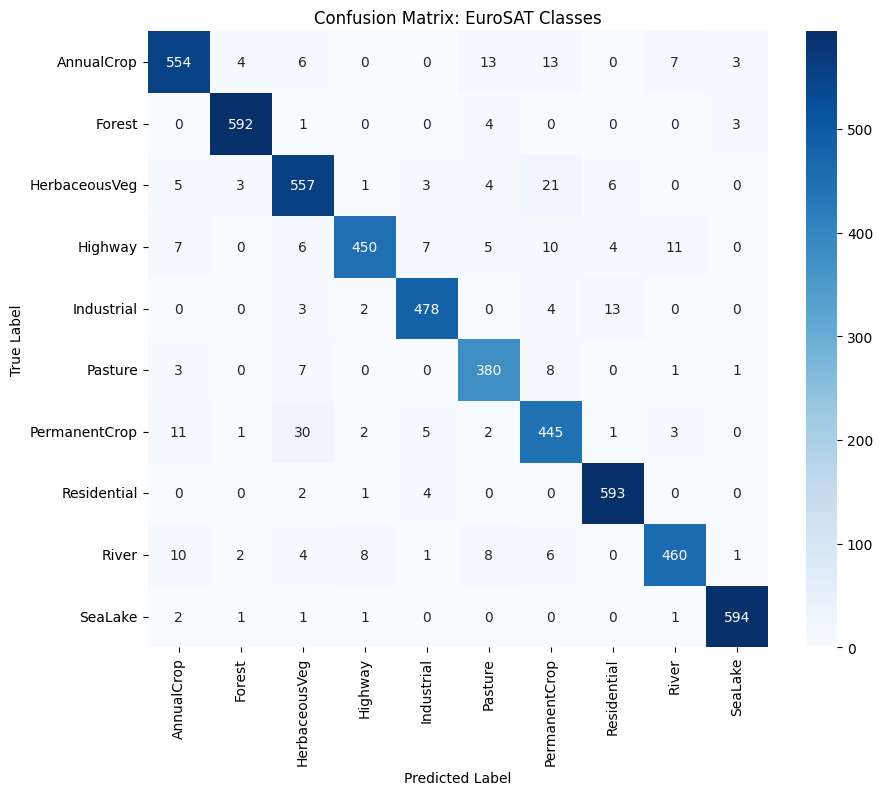

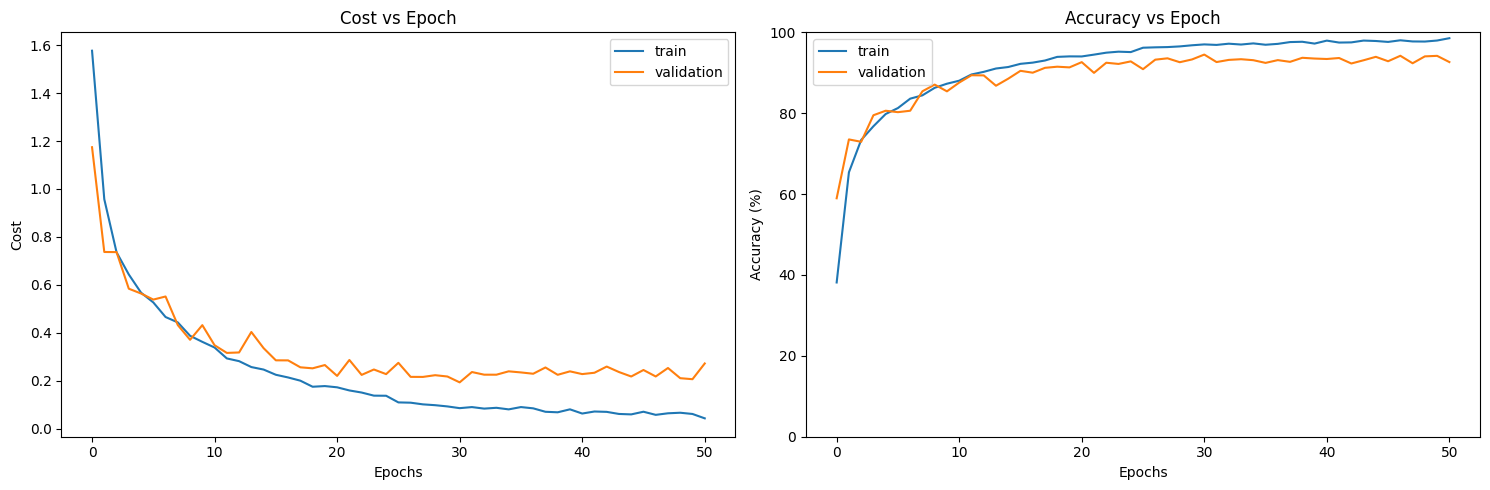

Training Accuracy: 98.55%
Validation Accuracy: 92.65%


In [63]:
train_acc_tf = [x * 100 for x in history.history['accuracy']]
val_acc_tf   = [x * 100 for x in history.history['val_accuracy']]
train_loss_tf = history.history['loss']
val_loss_tf   = history.history['val_loss']

# Get the final predictions
val_predictions_tf = model.predict(X_val_tf).argmax(axis=1)

# Plot confusion matrix
plot_euro_sat_confusion_matrix(y_val_gpu.get(), val_predictions_tf)

# Plot learning curves
plot_learning_curves(train_loss_tf, val_loss_tf, train_acc_tf, val_acc_tf)

print(f"Training Accuracy: {float(train_acc_tf[-1]):.2f}%")
print(f"Validation Accuracy: {float(val_acc_tf[-1]):.2f}%")

### Test Accuracy for TF

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9454 - loss: 0.1829
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


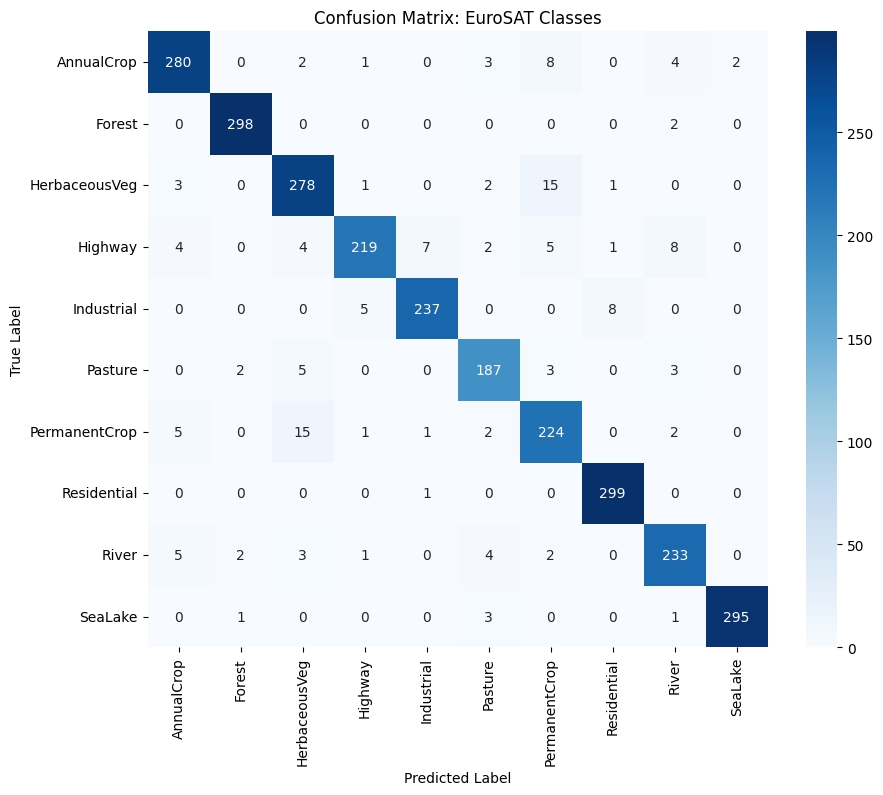

Test Accuracy: 94.44%


In [64]:
test_loss, test_acc = model.evaluate(X_test_tf, enc_y_test_transposed)

test_preds = model.predict(X_test_tf).argmax(axis=1)

plot_euro_sat_confusion_matrix(y_test, test_preds)

print(f"Test Accuracy: {test_acc*100:.2f}%")

In [65]:
model.save('models/CNN_tf.h5')
with open('CNN_tf_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)